In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'font.size': 14})

In [25]:
SEED = 42
np.random.seed(SEED) # NumPy
tf.random.set_seed(SEED) # TensorFlow

In [26]:
def createWindows(df, windowSize):

    # Separando as features e o target
    X = df.drop(columns=['valid_at', 'valore_originale', 'pm2p5_y']).values
    y = df['pm2p5_y'].values

    X_sep = []
    y_sep = []

    # 2. Deslizando a janela
    # O "+ 1" garante que a gente pegue a última janela possível no final do dataset
    for i in range(len(X) - windowSize + 1):
        
        # Pega o bloco de 20 linhas e já "amassa" (flatten) para virar um vetor de 120 colunas
        janela_features = X[i : i + windowSize].flatten()
        X_sep.append(janela_features)
        
        # O Alvo (y) é sempre o valor do PM2.5 referente à ÚLTIMA hora dessa janela.
        # O índice da última hora da janela é (i + windowSize - 1)
        alvo = y[i + windowSize - 1]
        y_sep.append(alvo)

    # 3. Convertendo as listas finais para Arrays do NumPy (O formato que a IA gosta)
    X_final = pd.DataFrame(np.array(X_sep))
    y_final = pd.DataFrame(np.array(y_sep))

    return X_final, y_final

In [27]:
totalFeatures = 6
windowSize    = 30
num_hidden    = 1024

## Ajustanto o Dataset utilizado

In [28]:
# Carregando os dados
ari_Mar_01 = pd.read_csv('Dados/ari-1727.csv')[::-1].reset_index(drop=True)
ari_Mar_02 = pd.read_csv('Dados/ari-1952.csv')[::-1].reset_index(drop=True)
ari_Mar_03 = pd.read_csv('Dados/ari-1953.csv')[::-1].reset_index(drop=True)
ari_Oct_01 = pd.read_csv('Dados/ari-1885.csv')[::-1].reset_index(drop=True)
ari_Oct_02 = pd.read_csv('Dados/ari-2049.csv')[::-1].reset_index(drop=True)
rf_01      = pd.read_csv('Dados/rf_1.csv')
rf_02      = pd.read_csv('Dados/rf_2.csv')

# Removendo as linhas com valores ausentes
ari_Mar_01.dropna(inplace=True)
ari_Mar_02.dropna(inplace=True)
ari_Mar_03.dropna(inplace=True)
ari_Oct_01.dropna(inplace=True)
ari_Oct_02.dropna(inplace=True)
rf_01     .dropna(inplace=True)
rf_02     .dropna(inplace=True)

# Convertendo a coluna 'valid_at' para o formato datetime
ari_Mar_01['valid_at'] = pd.to_datetime(ari_Mar_01['valid_at'])
ari_Mar_02['valid_at'] = pd.to_datetime(ari_Mar_02['valid_at'])
ari_Mar_03['valid_at'] = pd.to_datetime(ari_Mar_03['valid_at'])
ari_Oct_01['valid_at'] = pd.to_datetime(ari_Oct_01['valid_at'])
ari_Oct_02['valid_at'] = pd.to_datetime(ari_Oct_02['valid_at'])
rf_01     ['valid_at'] = pd.to_datetime(     rf_01['valid_at'])
rf_02     ['valid_at'] = pd.to_datetime(     rf_02['valid_at'])

# Ajustando o horario para o mesmo fuso GMT-0
rf_01['valid_at'] = rf_01['valid_at'] - pd.Timedelta(hours=1)
rf_02['valid_at'] = rf_02['valid_at'] - pd.Timedelta(hours=1)

# Arredondando os horários para o mais próximo possível
ari_Mar_01["valid_at"] = ari_Mar_01["valid_at"].dt.round("h")
ari_Mar_02["valid_at"] = ari_Mar_02["valid_at"].dt.round("h")
ari_Mar_03["valid_at"] = ari_Mar_03["valid_at"].dt.round("h")
ari_Oct_01["valid_at"] = ari_Oct_01["valid_at"].dt.round("h")
ari_Oct_02["valid_at"] = ari_Oct_02["valid_at"].dt.round("h")
rf_01     ["valid_at"] = rf_01     ["valid_at"].dt.round("h")
rf_02     ["valid_at"] = rf_02     ["valid_at"].dt.round("h")

# Realizando o merge dos DataFrames com base na coluna 'valid_at'
Data_Mar_01 = pd.merge(ari_Mar_01, rf_01, on='valid_at', how='inner')
Data_Mar_02 = pd.merge(ari_Mar_02, rf_01, on='valid_at', how='inner')
Data_Mar_03 = pd.merge(ari_Mar_03, rf_01, on='valid_at', how='inner')
Data_Oct_01 = pd.merge(ari_Oct_01, rf_02, on='valid_at', how='inner')
Data_Oct_02 = pd.merge(ari_Oct_02, rf_02, on='valid_at', how='inner')

# Criando as janelas de dados para cada DataFrame
X_Mar_01, y_Mar_01 = createWindows(Data_Mar_01, windowSize)
X_Mar_02, y_Mar_02 = createWindows(Data_Mar_02, windowSize)
X_Mar_03, y_Mar_03 = createWindows(Data_Mar_03, windowSize)
X_Oct_01, y_Oct_01 = createWindows(Data_Oct_01, windowSize)
X_Oct_02, y_Oct_02 = createWindows(Data_Oct_02, windowSize)

# Concatenando os conjuntos de features (X) e alvos (y) de todos os DataFrames
X = pd.concat([X_Mar_01, X_Mar_02, X_Mar_03, X_Oct_01, X_Oct_02], ignore_index=True)
y = pd.concat([y_Mar_01, y_Mar_02, y_Mar_03, y_Oct_01, y_Oct_02], ignore_index=True)

# Dividindo os dados em conjuntos de treino, validação e teste
X_train, X_aux, y_train, y_aux = train_test_split(    X,     y, train_size=0.75, random_state=42)
X_val, X_test, y_val, y_test   = train_test_split(X_aux, y_aux, train_size=0.50, random_state=42)

X_train.sort_index(inplace=True)
X_val  .sort_index(inplace=True)
X_test .sort_index(inplace=True)
X_aux  .sort_index(inplace=True)

y_train.sort_index(inplace=True)
y_val  .sort_index(inplace=True)
y_test .sort_index(inplace=True)
y_aux  .sort_index(inplace=True)


scaler_X = StandardScaler()
X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(scaler_X.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test  = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index)

#Normalizando os dados de saida
scaler_y = StandardScaler()
y_train = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=['target'], index=y_train.index)
y_val   = pd.DataFrame(scaler_y.transform(y_val.values.reshape(-1, 1)), columns=['target'], index=y_val.index)


## Modelo da MLP

In [29]:
model = Sequential()

# Define a porta de entrada (o tamanho do input)
model.add(Input(shape=(totalFeatures*windowSize,)))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(1))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1024)           │       185,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,335,169 (12.72 MB)

 Trainable params: 3,335,169 (12.72 MB)

 Non-trainable params: 0 (0.00 B)

### Compilação do modelo de MLP

In [30]:
# Compilando o modelo com r1loss
model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.000352))

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # val_loss       
    patience=15,                 
    restore_best_weights=True,   
    verbose=1                    
)

### Treinamento do modelo MLP

In [31]:
# Treinando o modelo
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,                     
    batch_size=64,                  
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.4982 - val_loss: 0.4153
Epoch 2/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.3961 - val_loss: 0.3698
Epoch 3/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3509 - val_loss: 0.3474
Epoch 4/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.3117 - val_loss: 0.3320
Epoch 5/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2872 - val_loss: 0.3217
Epoch 6/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2736 - val_loss: 0.3060
Epoch 7/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.2574 - val_loss: 0.3053
Epoch 8/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2383 - val_loss: 0.2900
Epoch 9/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2309 - val_loss: 0.2809
Epoch 10/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2192 - val_loss: 0.2720
Epoch 11/200
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2154 - val_loss: 0.2894
Epoch 12/200
215/215 ━━━━━━━━━

In [ ]:
#model.save('Modelos/modelo_AirMLP7_1500_Melhorado.keras')

In [ ]:
model = load_model('Modelos/modelo_AirMLP7_1500_Melhorado.keras')

# 1. Faz as previsões (elas sairão em formato escalado)
y_test_pred_scaled = model.predict(X_test)

# 2. Reverte a escala para os valores reais (ug/m3)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Resultados

## Resultado da evolução dos erros durante o treinamento

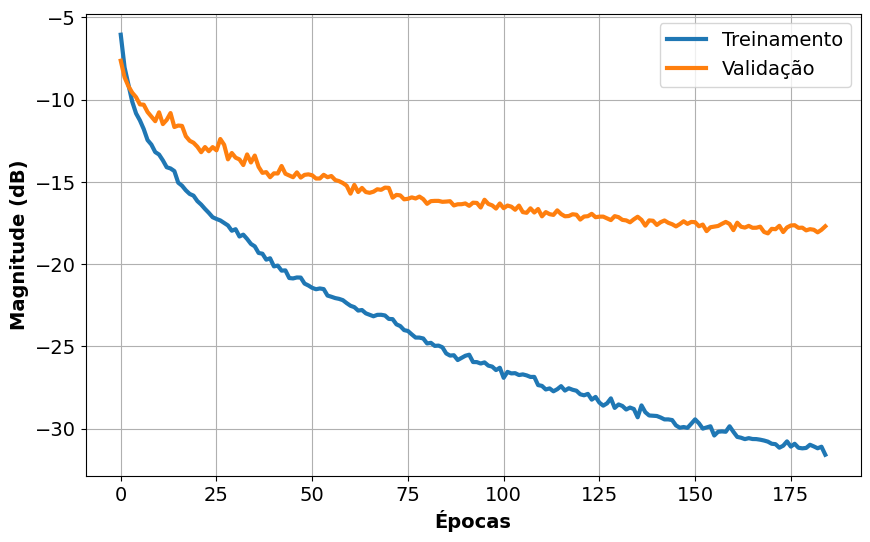

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(20*np.log10(history.history['loss']), linewidth=3)
plt.plot(20*np.log10(history.history['val_loss']), linewidth=3)
plt.ylabel('Magnitude (dB)', fontweight='bold')
plt.xlabel('Épocas', fontweight='bold')
plt.legend(['Treinamento', 'Validação'], loc='upper right')
plt.grid()

### Resultado da estimativa para os dados de teste

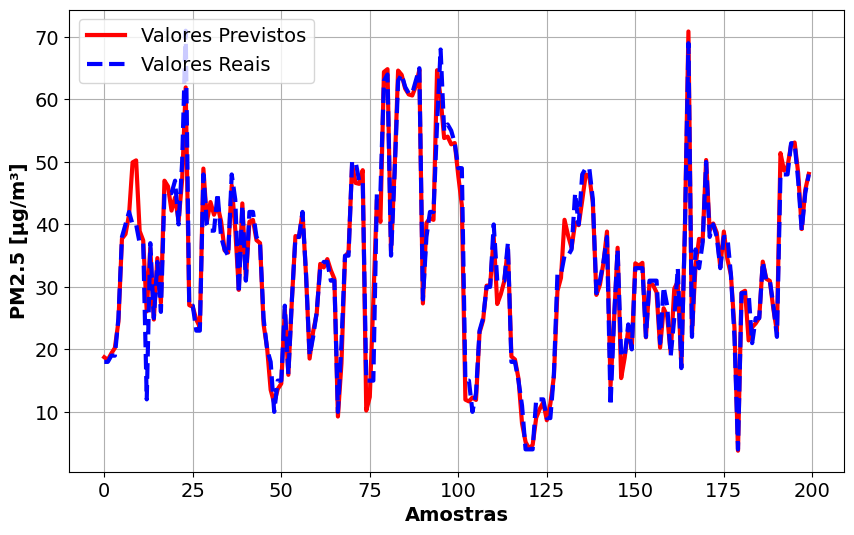

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_pred[:200], 'r-', label='Valores Previstos', linewidth=3)
plt.plot(y_test.values[:200], 'b--', label='Valores Reais', linewidth=3)
plt.xlabel('Amostras', fontweight='bold')
plt.ylabel('PM2.5 [μg/m³]', fontweight='bold')
plt.grid()
plt.legend()

### Resultado do Scatter Plot

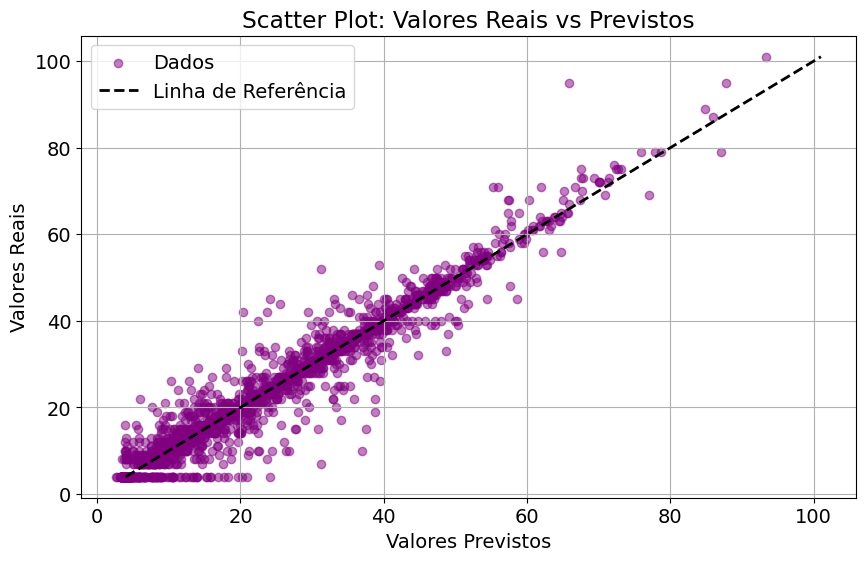

In [36]:
# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, y_test.values, color='purple', alpha=0.5, label='Dados')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Linha de Referência')  # Linha de referência y=x
plt.title('Scatter Plot: Valores Reais vs Previstos')
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.grid()
plt.legend()

### Métricas de Erro

In [37]:
# Metricas de erro e R2
mae = mean_absolute_error(y_test.values, y_test_pred)
rmse = root_mean_squared_error(y_test.values, y_test_pred)
r2 = r2_score(y_test.values, y_test_pred)
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

'''0.9488'''

MAE: 2.0528
RMSE: 3.7522
R2: 0.9438


'0.9488'